In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [7]:
df = pd.read_csv("cleaned_dataset1.csv")
df['Date_of_investing'] = pd.to_datetime(df['Date_of_investing'])

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17800 entries, 0 to 17799
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Date_of_investing     17800 non-null  datetime64[ns]
 1   Index_Name            17800 non-null  object        
 2   Country               17800 non-null  object        
 3   Open                  17800 non-null  float64       
 4   High                  17800 non-null  float64       
 5   Low                   17800 non-null  float64       
 6   Close                 17800 non-null  float64       
 7   Volume                17416 non-null  float64       
 8   Daily_Change_Percent  17800 non-null  float64       
dtypes: datetime64[ns](1), float64(6), object(2)
memory usage: 1.2+ MB


In [9]:
df['Year'] = df['Date_of_investing'].dt.year

In [10]:
df.tail()

,Date_of_investing,Index_Name,Country,Open,High,Low,Close,Volume,Daily_Change_Percent,Year
17795,2022-10-17,NASDAQ Composite,Usa,10786.27,11052.66,10681.17,10949.12,43691278.0,1.51,2022
17796,2022-07-26,Dow Jones,Usa,23164.70,23892.67,23037.70,23595.56,28096476.0,1.86,2022
17797,2021-12-30,NASDAQ Composite,Usa,32881.12,33099.99,32397.70,32414.65,35073989.0,-1.42,2021
17798,2024-11-07,SSE Composite,China,17572.11,17808.43,17047.40,17330.62,29478663.0,-1.37,2024
17799,2024-11-02,FTSE 100,Uk,5549.21,5703.43,5322.16,5590.65,20082696.0,0.75,2024


""" 1. Date_of_investing  : The date when the stock market data was recorded.

2. Index_Name         : Name of the stock market index.

3. Country            : Country where the stock index belongs.

4. Open               : Price at which the index opened when market started that day.

5. High               : Highest price reached during the day.

6. Low                : Lowest price reached during that day.

7. Close              : Final price when market closes.

8. Volume             : Total number of shares/contracts traded that day.

9. Daily_Change_Percent: Percentage change in price during the day.  """

In [11]:
df.isnull().sum()

Date_of_investing         0
Index_Name                0
Country                   0
Open                      0
High                      0
Low                       0
Close                     0
Volume                  384
Daily_Change_Percent      0
Year                      0
dtype: int64

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17800 entries, 0 to 17799
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Date_of_investing     17800 non-null  datetime64[ns]
 1   Index_Name            17800 non-null  object        
 2   Country               17800 non-null  object        
 3   Open                  17800 non-null  float64       
 4   High                  17800 non-null  float64       
 5   Low                   17800 non-null  float64       
 6   Close                 17800 non-null  float64       
 7   Volume                17416 non-null  float64       
 8   Daily_Change_Percent  17800 non-null  float64       
 9   Year                  17800 non-null  int32         
dtypes: datetime64[ns](1), float64(6), int32(1), object(2)
memory usage: 1.3+ MB


In [13]:
numeric_cols=df.select_dtypes(include=['float64','int32'])
categorical_cols=df.select_dtypes(include=['object'])

### correlation map

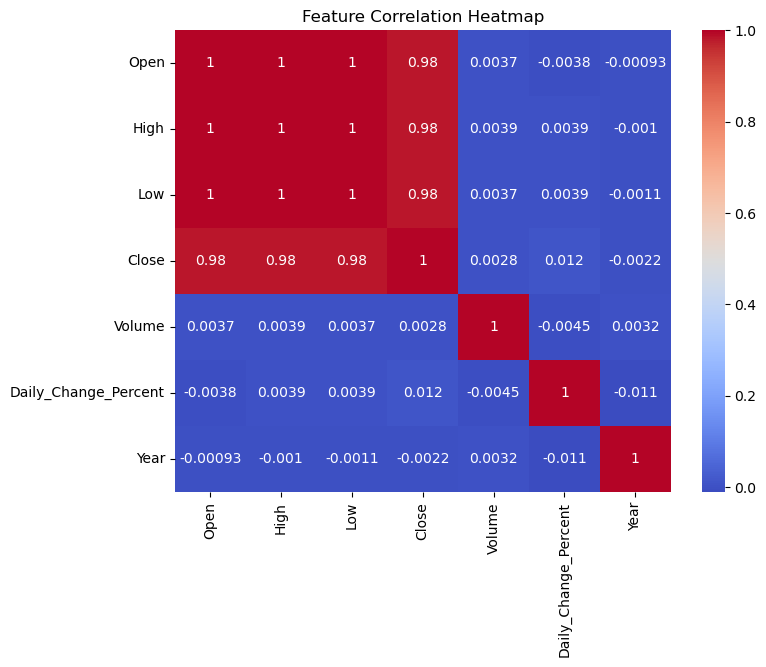

In [14]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Feature Correlation Heatmap")
plt.show()

##### Insight : This heatmap shows that stock price features (Open, High, Low, Close) are strongly positively correlated, while Volume, Daily Change Percent, and Year have weak or negligible correlation with other variables, indicating independent behavior.

### County wise Index names

In [15]:
country_index_count = df.groupby('Country')['Index_Name'].nunique()
country_index_count

Country
China        1
France       1
Germany      1
Hong kong    1
Japan        1
Pakistan     1
Uk           1
Usa          3
Name: Index_Name, dtype: int64

<Axes: ylabel='Index_Name'>

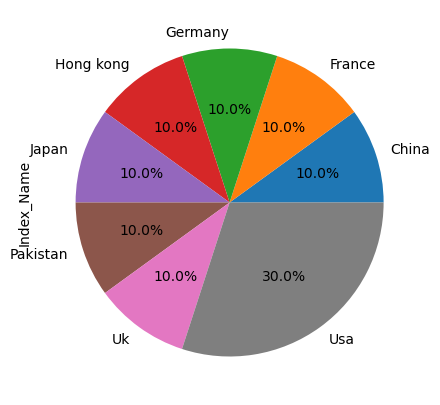

In [16]:
plt.figure(figsize=(5,5))
country_index_count.plot(kind='pie',autopct='%1.1f%%')


##### insight : The pie chart illustrates the country-wise proportion of index data. The USA contributes the largest share at 30%, while China, France, Germany, Hong Kong, Japan, Pakistan, and the UK each contribute an equal 10%, showing a mostly balanced distribution with one dominant country.

In [17]:
df

,Date_of_investing,Index_Name,Country,Open,High,Low,Close,Volume,Daily_Change_Percent,Year
0,2020-11-15,NASDAQ Composite,Usa,11361.46,11934.64,11323.18,11797.26,47514127.0,3.84,2020
1,2021-08-30,FTSE 100,Uk,10298.33,10829.50,10194.32,10736.46,1471464.0,4.25,2021
2,2024-08-30,DAX,Germany,38316.88,38323.86,38236.10,38311.46,19307568.0,-0.01,2024
3,2022-07-10,S&P 500,Usa,14066.68,14599.10,13969.65,38311.46,7663563.0,2.35,2022
4,2020-08-07,SSE Composite,China,37095.64,37457.27,37063.21,37424.57,26746244.0,0.89,2020
...,...,...,...,...,...,...,...,...,...,...
17795,2022-10-17,NASDAQ Composite,Usa,10786.27,11052.66,10681.17,10949.12,43691278.0,1.51,2022
17796,2022-07-26,Dow Jones,Usa,23164.70,23892.67,23037.70,23595.56,28096476.0,1.86,2022
17797,2021-12-30,NASDAQ Composite,Usa,32881.12,33099.99,32397.70,32414.65,35073989.0,-1.42,2021
17798,2024-11-07,SSE Composite,China,17572.11,17808.43,17047.40,17330.62,29478663.0,-1.37,2024


### opening and closing stock market relation

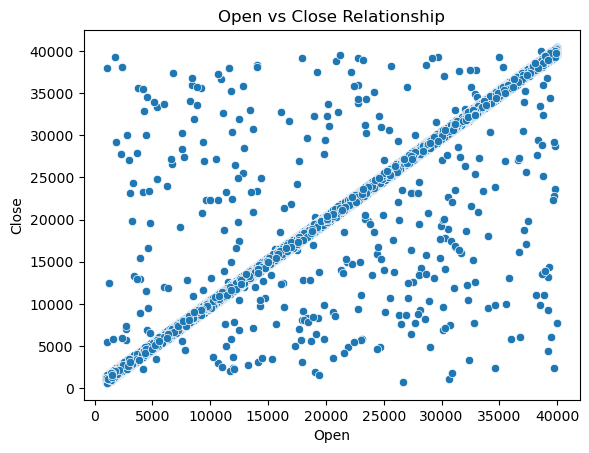

In [18]:
sns.scatterplot(x='Open', y='Close', data=df)
plt.title("Open vs Close Relationship")
plt.show()

##### insight : The scatter plot shows that Open and Close prices are highly related. Stocks that open at higher prices generally close at higher prices, indicating strong consistency in daily price movement.

### Average close price by country

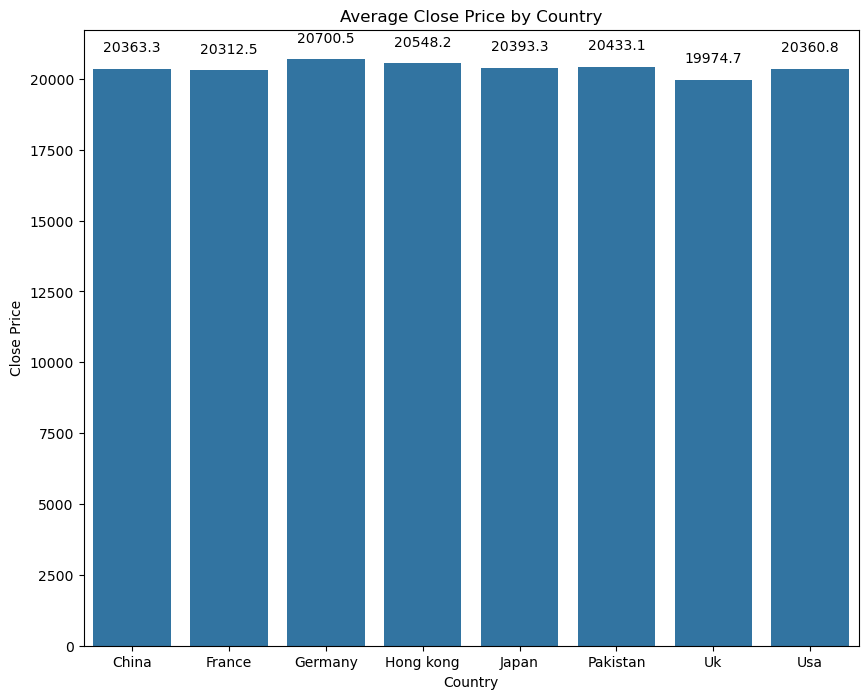

In [19]:
plt.figure(figsize=(10,8))
country_avg = df.groupby('Country')['Close'].mean()
ax=sns.barplot(country_avg)
#country_avg.plot(kind='bar')
for container in ax.containers:
    ax.bar_label(container,padding=10)
plt.title("Average Close Price by Country")
plt.ylabel("Close Price")
plt.show()

##### insight : The bar chart shows that the average close prices are almost similar for all countries, with Germany having the highest value and the UK the lowest, indicating only small variations between countries.

### Market index Distribution : Which index dominates the dataset

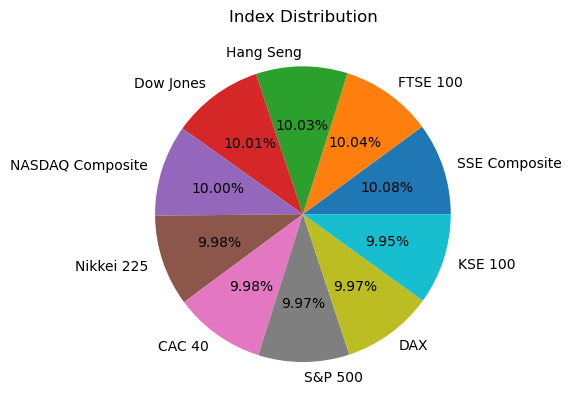

In [20]:
index_count = df['Index_Name'].value_counts()
index_count

index_count.plot(kind='pie', autopct='%1.2f%%')
plt.title("Index Distribution")
plt.ylabel("")
plt.show()

##### insight : The pie chart shows that all stock market indices are almost equally distributed, each contributing around 10% of the dataset, indicating a balanced representation of indices.

### time vs price trend

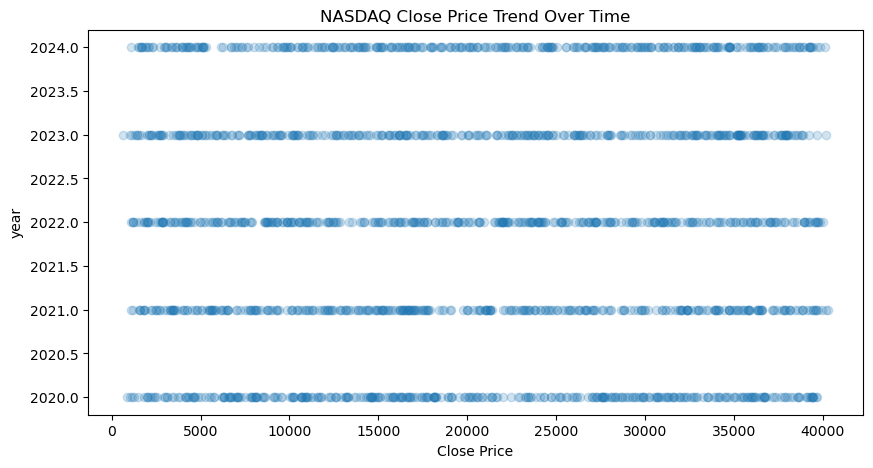

In [21]:
plt.figure(figsize=(10,5))

sample = df[df['Index_Name'] == 'NASDAQ Composite']

plt.scatter(sample['Close'],sample['Year'],alpha=0.2)

plt.title("NASDAQ Close Price Trend Over Time")
plt.ylabel("year")
plt.xlabel("Close Price")
plt.show()

##### insight : This scatter plot shows NASDAQ close prices for different years, where each year has a wide range of prices and a similar distribution, indicating no obvious yearly trend in this visualization.

### multiple index names closing price value relation

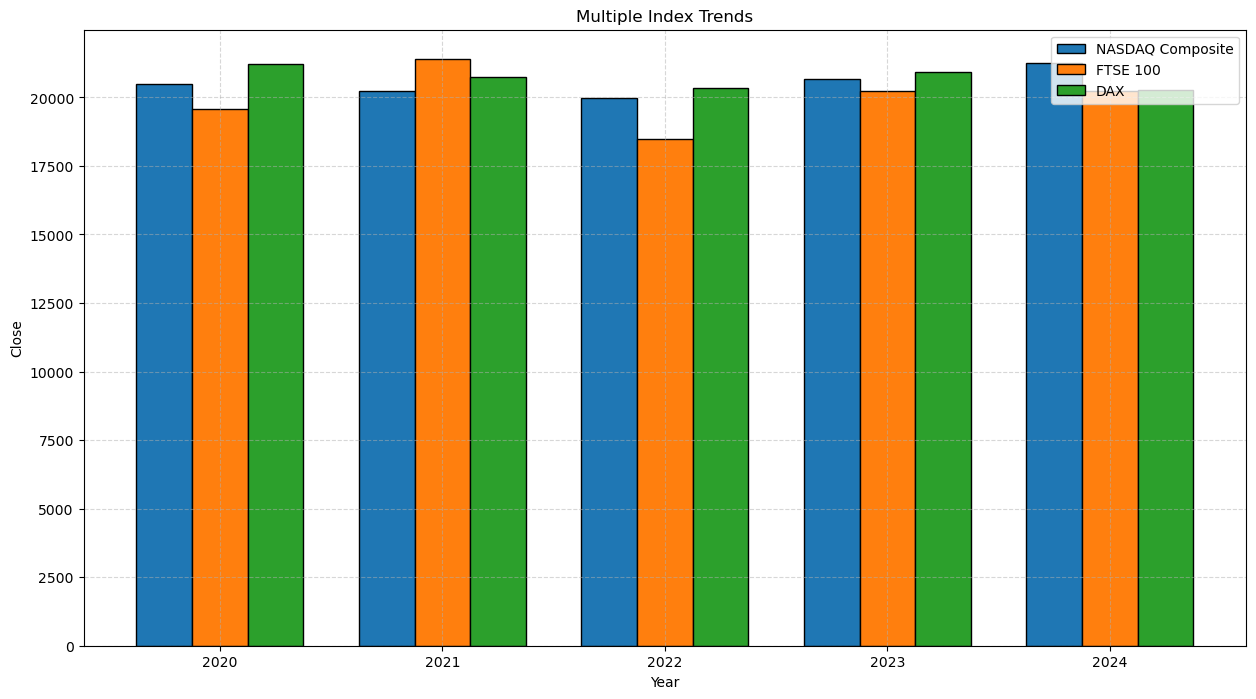

In [22]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))

years = sorted(df['Year'].unique())
x = np.arange(len(years))
width = 0.25

for i, name in enumerate(df['Index_Name'].unique()[:3]):
    
    temp = df[df['Index_Name'] == name]
    
    # FIX → remove duplicates using groupby
    temp = temp.groupby('Year')['Close'].mean()

    # reindex safely
    values = temp.reindex(years)

    plt.bar(x + i*width, values, width=width, label=name,edgecolor='black')

plt.xticks(x + width, years)
plt.legend(loc='upper right')
plt.title("Multiple Index Trends")
plt.xlabel("Year")
plt.ylabel("Close")

plt.grid(True,linestyle="--",alpha=0.5)
plt.show()

##### insight : This grouped bar chart compares NASDAQ Composite, FTSE 100, and DAX close values from 2020 to 2024. NASDAQ shows steady growth, FTSE 100 fluctuates with a dip in 2022, and DAX remains relatively stable with consistently high values.

### Volatility Analysis

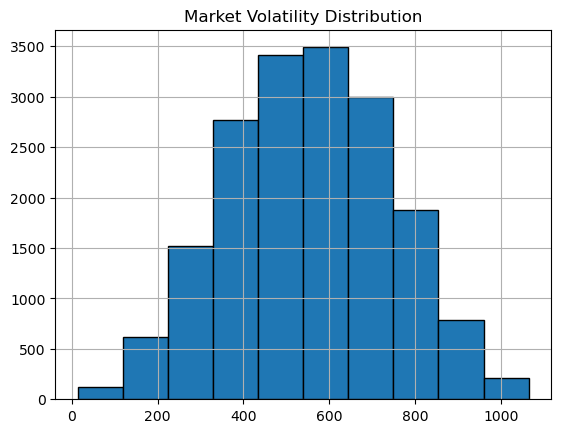

In [23]:
df['Volatility'] = df['High'] - df['Low']

df['Volatility'].hist(edgecolor='black')
plt.title("Market Volatility Distribution")
plt.show()

##### insight : This histogram shows that market volatility mostly falls in the middle range (around 500–600), forming a bell-shaped distribution, while extremely low or high volatility occurs less often.

### High-Low Price over time

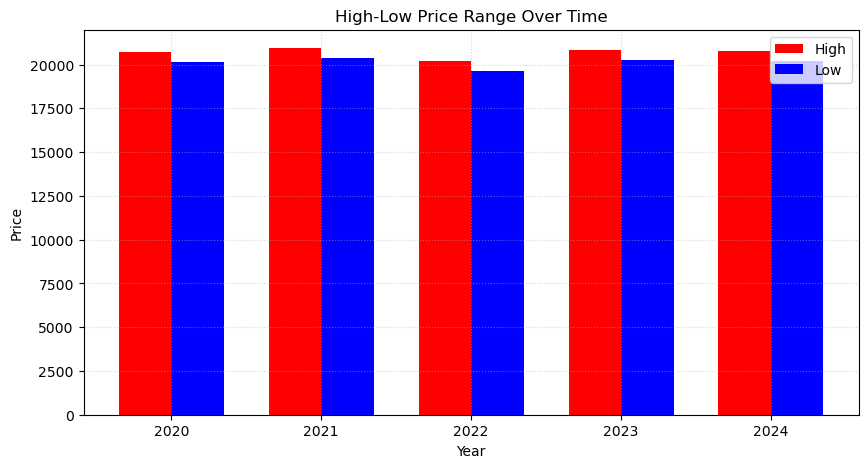

In [33]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

years = sorted(df['Year'].unique())
x = np.arange(len(years))
width = 0.35

# Aggregate values per year (important!)
high_values = df.groupby('Year')['High'].mean().reindex(years)
low_values  = df.groupby('Year')['Low'].mean().reindex(years)

# High bars
plt.bar(x - width/2, high_values, width=width, label='High',color='red')

# Low bars
plt.bar(x + width/2, low_values, width=width, label='Low',color='blue')

plt.xticks(x, years)

plt.title("High-Low Price Range Over Time")
plt.xlabel("Year")
plt.ylabel("Price")
plt.legend()
plt.grid(True,alpha=0.5,linestyle=':')
plt.show()

##### insight : This chart compares yearly High and Low prices from 2020 to 2024. High prices are consistently above Low prices, with only small differences between them, showing stable market price ranges over time.

### Pairplot

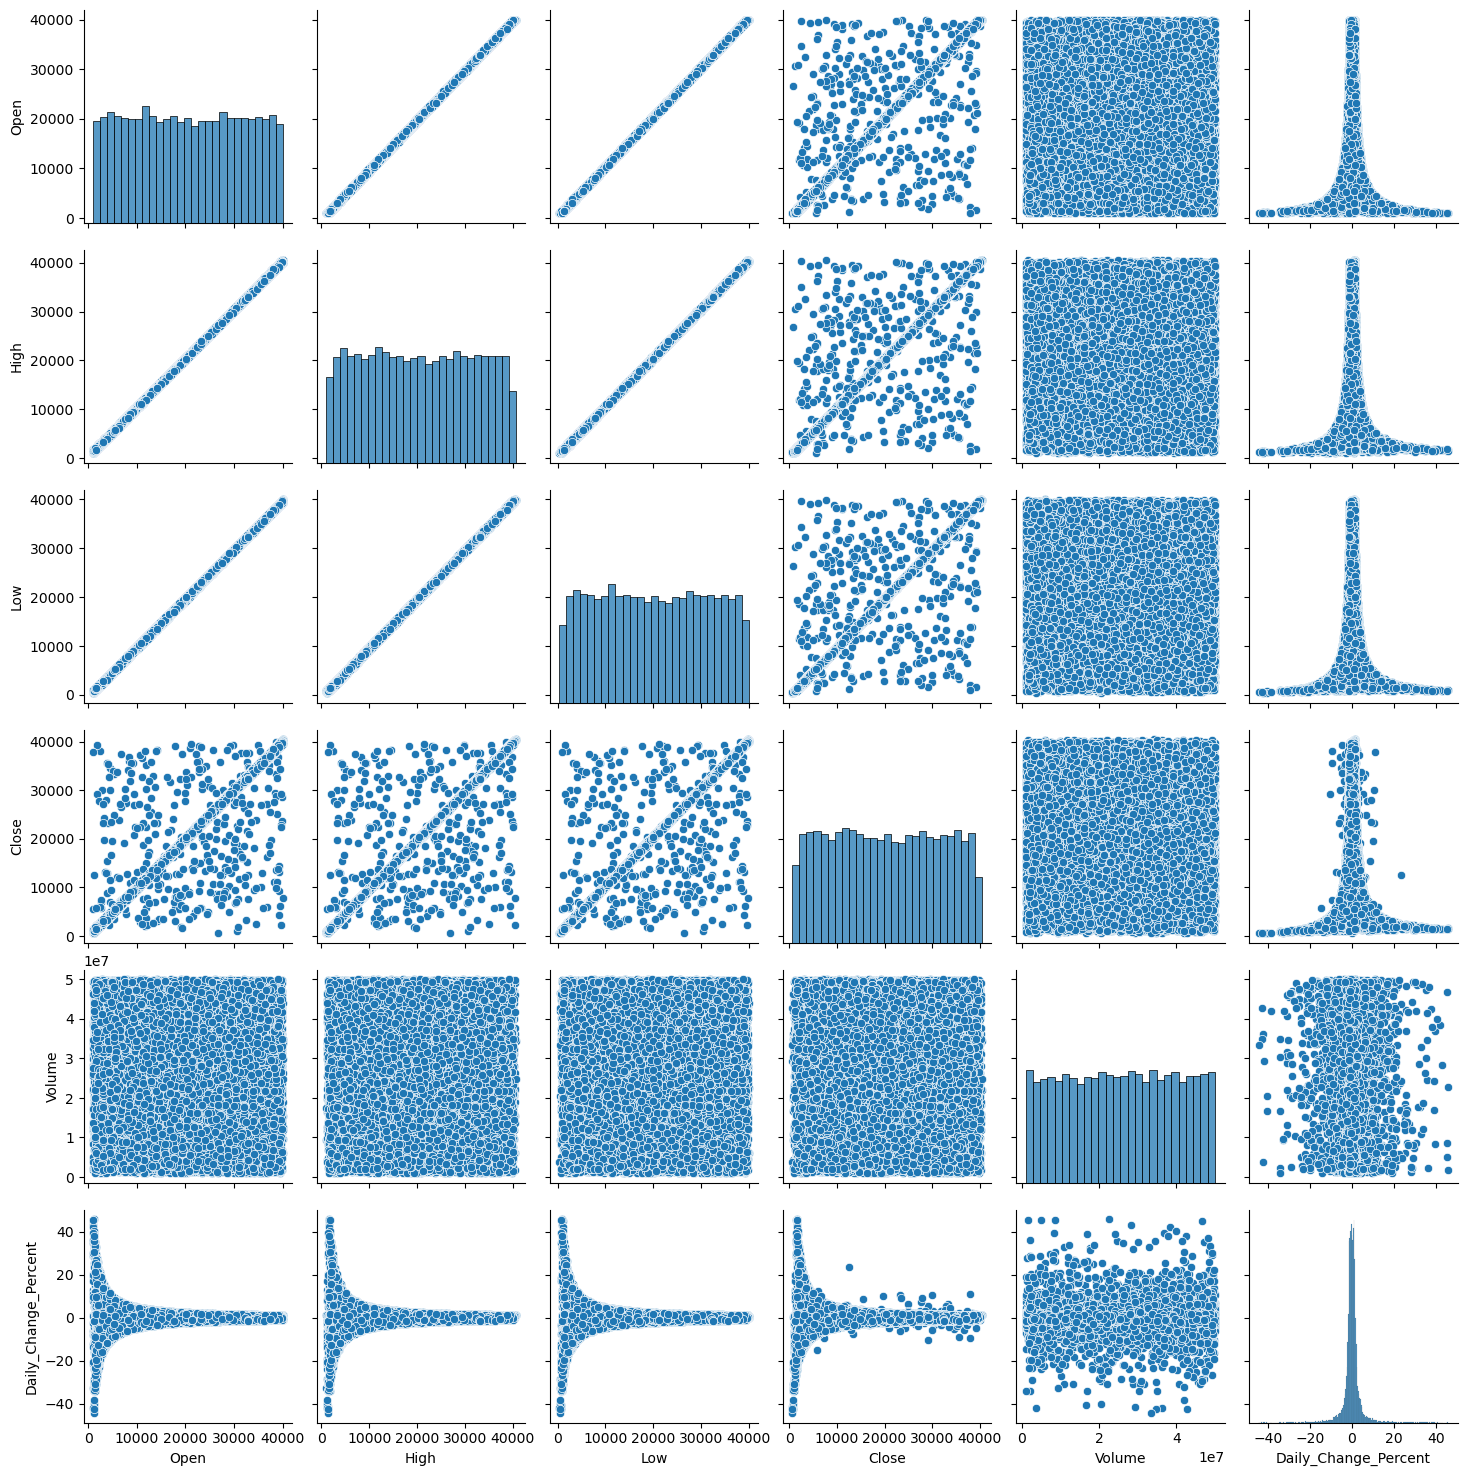

In [25]:
sns.pairplot(df[['Open','High','Low','Close',
                 'Volume','Daily_Change_Percent']])
plt.show()

##### insight : This pair plot shows strong relationships among price features (Open, High, Low, Close), while Volume and Daily Change Percent have weak or random relationships with other variables. It provides a complete overview of feature distributions and correlations in the datase

### Average Monthly Close Price

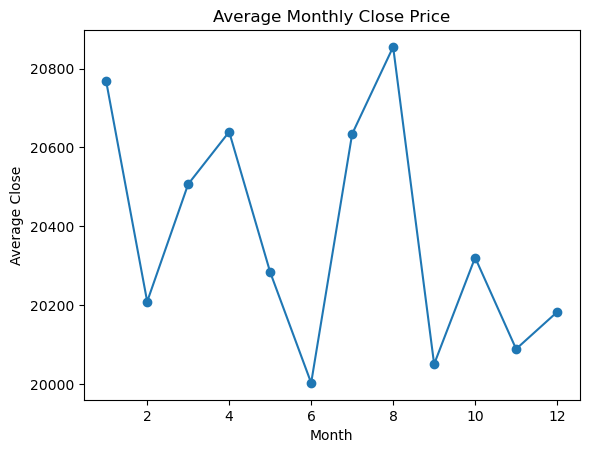

In [26]:
df['Month'] = df['Date_of_investing'].dt.month

monthly_avg = df.groupby('Month')['Close'].mean()

monthly_avg.plot(kind='line', marker='o')
plt.title("Average Monthly Close Price")
plt.xlabel("Month")
plt.ylabel("Average Close")
plt.show()

##### insight : This line chart shows monthly changes in average close price, with fluctuations throughout the year, a peak around month 8, and a low around month 6, indicating varying market performance across months

### Daily Change % by Index

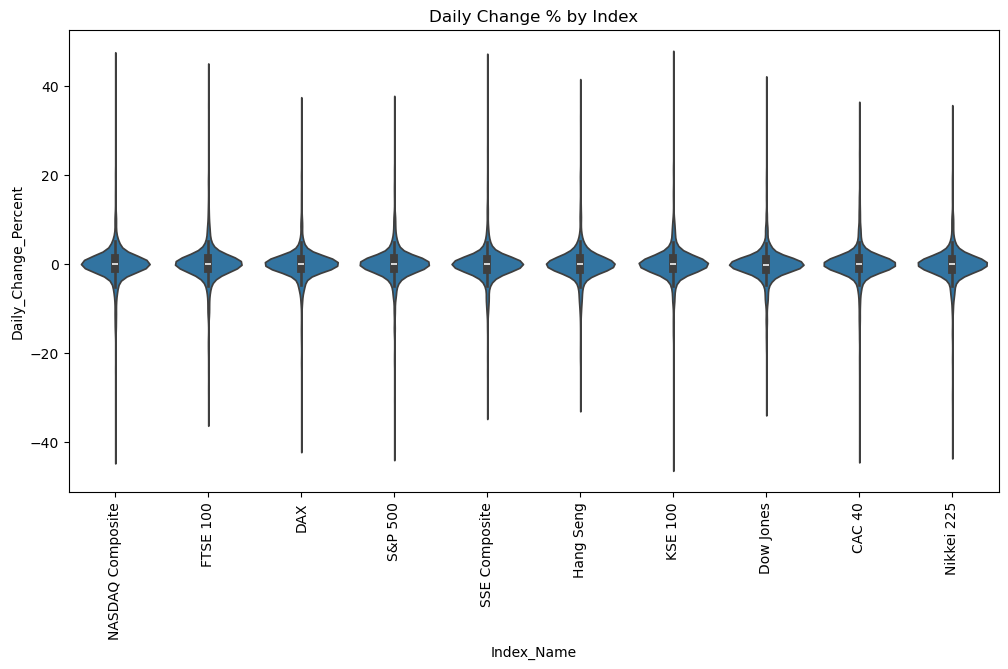

In [27]:
plt.figure(figsize=(12,6))
sns.violinplot(x='Index_Name', y='Daily_Change_Percent', data=df)

plt.xticks(rotation=90)
plt.title("Daily Change % by Index")
plt.show()

##### insight : This violin plot shows that daily percentage changes for all indices are mostly centered around zero, meaning small daily movements are common, while extreme gains or losses occur less frequently.

### varying closing price by year

<Axes: xlabel='Year', ylabel='Close'>

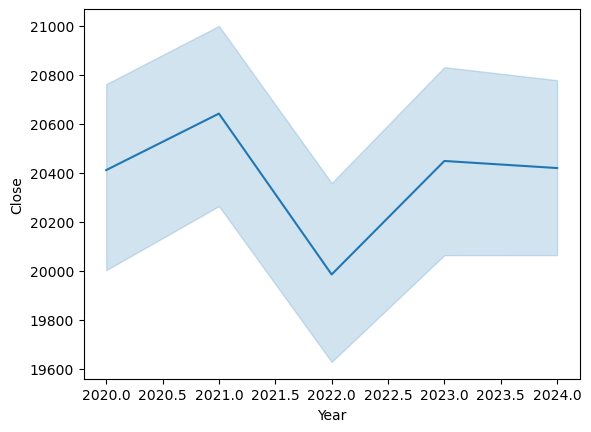

In [28]:
sns.lineplot(x='Year',y='Close',data=df)

##### insight : This chart shows yearly close price trends with variation. Prices rise from 2020 to 2021, fall in 2022, then recover and stabilize during 2023–2024.

### Price distributions in market

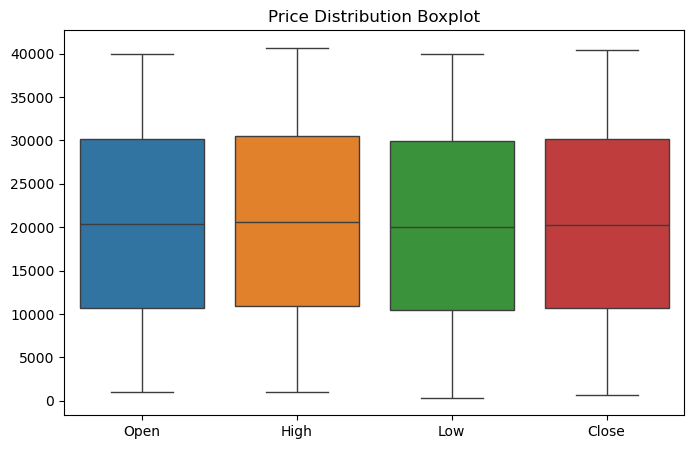

In [29]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df[['Open','High','Low','Close']])

plt.title("Price Distribution Boxplot")
plt.show()

##### insight : This boxplot compares Open, High, Low, and Close prices and shows that all have similar distributions with median values around 20,000 and a wide price range, indicating consistent behavior across price features.

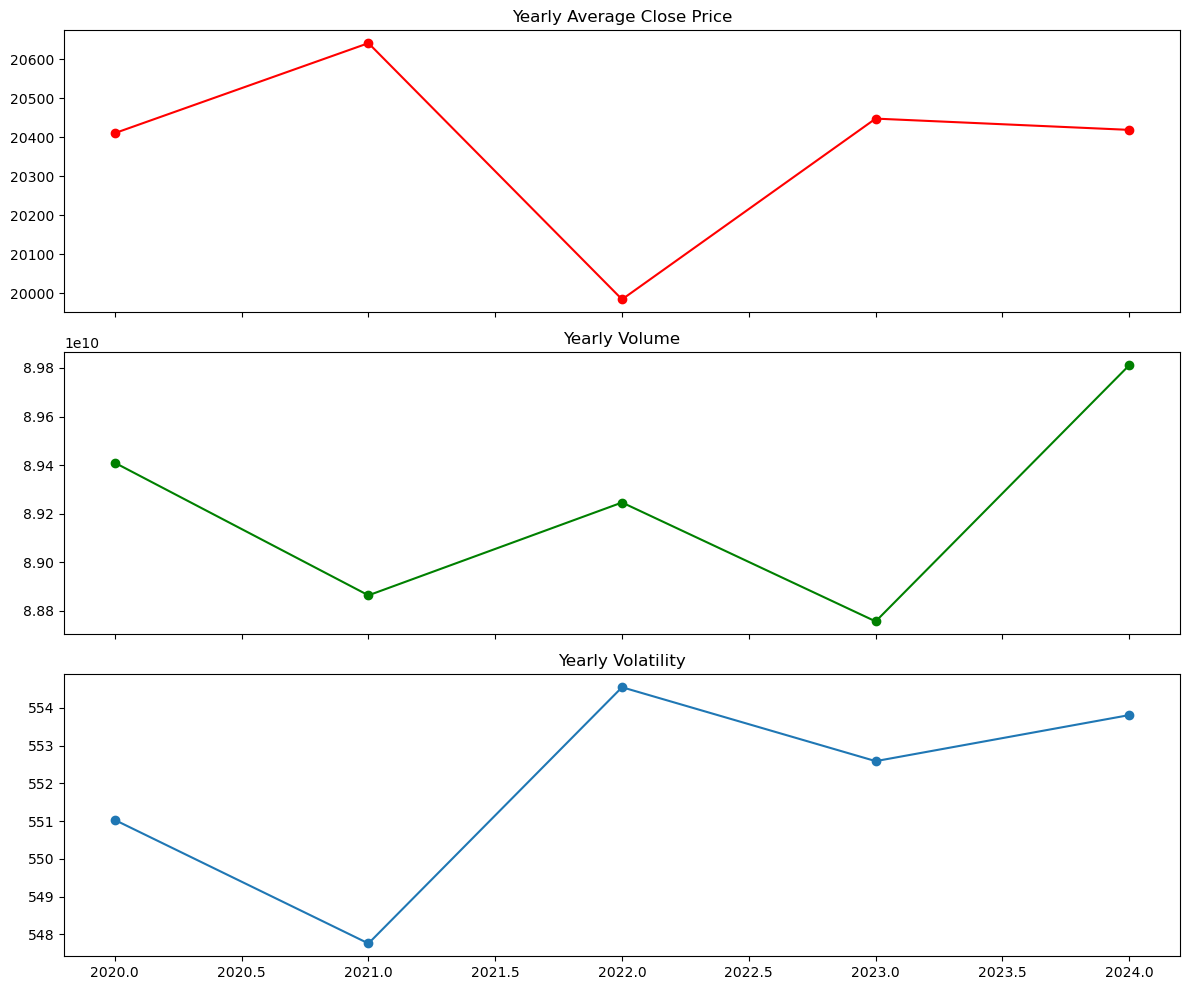

In [30]:
yearly = df.groupby('Year').agg({
    'Close':'mean',
    'Volume':'sum',
    'High':'mean',
    'Low':'mean'
}).reset_index()

fig, axes = plt.subplots(3, 1, figsize=(12,10), sharex=True)

axes[0].plot(yearly['Year'], yearly['Close'],color='red',marker='o')
axes[0].set_title("Yearly Average Close Price")

axes[1].plot(yearly['Year'], yearly['Volume'],color='green',marker='o')
axes[1].set_title("Yearly Volume")

axes[2].plot(yearly['Year'], yearly['High'] - yearly['Low'],marker='o')
axes[2].set_title("Yearly Volatility")

plt.tight_layout()
plt.show()

##### insight : This chart compares yearly close price, volume, and volatility. The close price drops and volatility peaks in 2022, while volume fluctuates across years. After 2022, prices recover and the market becomes more stable.

<Figure size 1500x500 with 0 Axes>

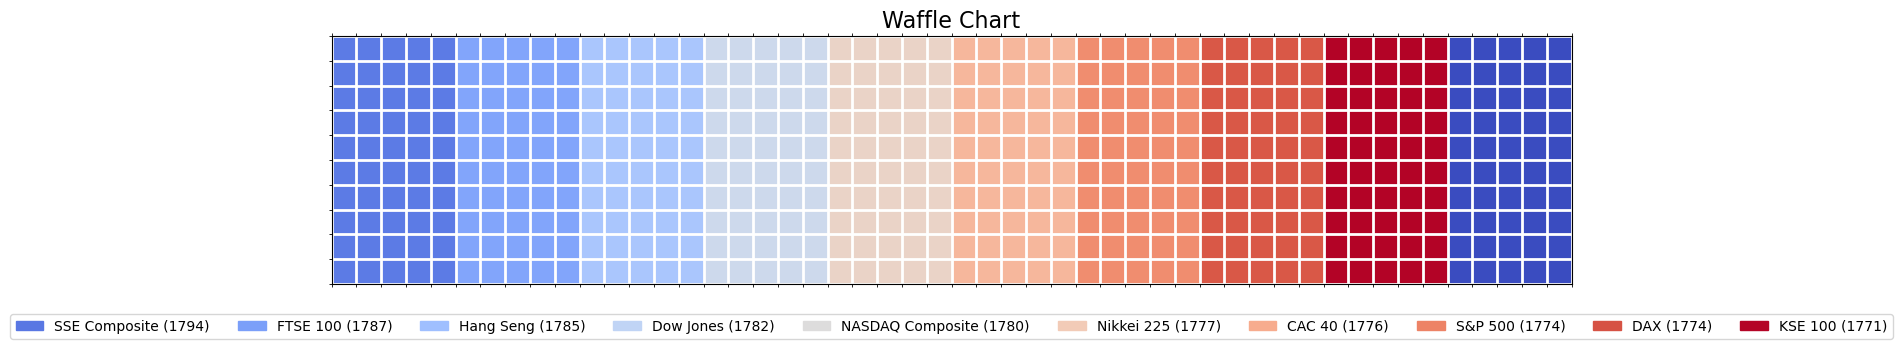

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Load dataset
df = pd.read_csv("cleaned_dataset1.csv")

# Choose column (you can change this)
category_counts = df['Index_Name'].value_counts()

categories = category_counts.index.tolist()
values = category_counts.values.tolist()

def create_waffle_chart(categories, values, height, width, colormap):

    total_values = sum(values)
    proportions = [v / total_values for v in values]

    total_tiles = width * height
    tiles_per_category = [round(p * total_tiles) for p in proportions]

    # Create empty grid
    waffle_chart = np.zeros((height, width))

    category_index = 0
    tile_index = 0

    for col in range(width):
        for row in range(height):
            tile_index += 1

            if tile_index > sum(tiles_per_category[:category_index]):
                category_index += 1

            if category_index < len(categories):
                waffle_chart[row, col] = category_index

    # Plot
    plt.figure(figsize=(15, 5))
    plt.matshow(waffle_chart, cmap=colormap)
    plt.xticks([])
    plt.yticks([])

    # Add white grid lines (like your image)
    ax = plt.gca()
    ax.set_xticks(np.arange(-.5, width, 1), minor=True)
    ax.set_yticks(np.arange(-.5, height, 1), minor=True)
    ax.grid(which='minor', color='white', linestyle='-', linewidth=2)

    # Legend (like your image)
    cumulative = np.cumsum(values)
    total = cumulative[-1]

    legend_handles = []
    for i, category in enumerate(categories):
        label = f"{category} ({values[i]})"
        color = colormap(float(cumulative[i]) / total)
        legend_handles.append(mpatches.Patch(color=color, label=label))

    plt.legend(
        handles=legend_handles,
        loc='lower center',
        ncol=len(categories),
        bbox_to_anchor=(0.5, -0.25)
    )

    plt.title("Waffle Chart", fontsize=16)
    plt.show()


# Call function
create_waffle_chart(
    categories,
    values,
    height=10,     # rows
    width=50,      # columns (wide like your image)
    colormap=plt.cm.coolwarm
)

In [4]:
!conda install -c conda-forge wordcloud --yes


CondaToSNonInteractiveError: Terms of Service have not been accepted for the following channels. Please accept or remove them before proceeding:
    - https://repo.anaconda.com/pkgs/main
    - https://repo.anaconda.com/pkgs/r

To accept these channels' Terms of Service, run the following commands:
    conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/main
    conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/r

For information on safely removing channels from your conda configuration,
please see the official documentation:

    https://www.anaconda.com/docs/tools/working-with-conda/channels



In [11]:
!pip install wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 550.7/550.7 kB 177.6 kB/s  0:00:04eta 0:00:01


In [12]:
from wordcloud import WordCloud, STOPWORDS

In [ ]:
from wordcloud import WordCloud, STOPWORDS

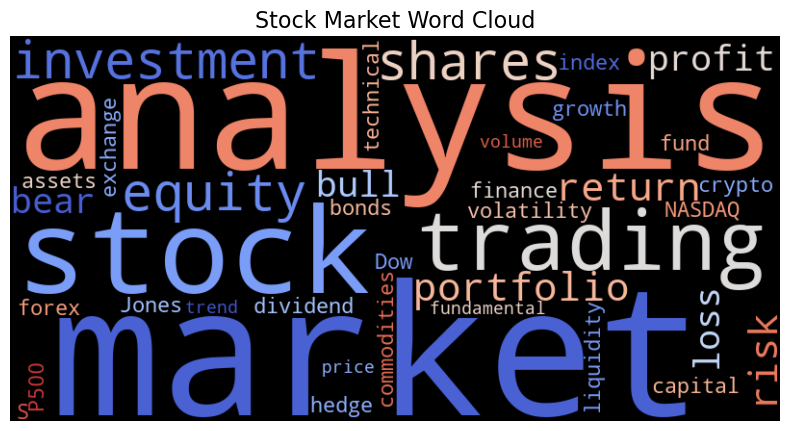

In [13]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Stock market related words
text = """
stock market trading investment shares equity portfolio risk return profit loss
bull bear volatility index NASDAQ S&P500 Dow Jones exchange finance capital
dividend bonds commodities crypto forex liquidity assets hedge fund growth
technical analysis fundamental analysis market trend price volume
"""

# Create word cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='black',
    colormap='coolwarm'
).generate(text)

# Display
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Stock Market Word Cloud", fontsize=16)
plt.show()

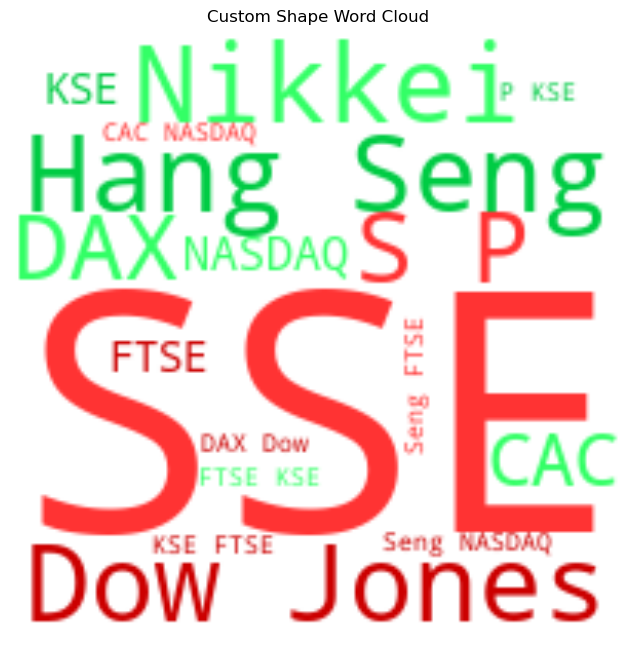

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
from PIL import Image
import random

# Load dataset
df = pd.read_csv("cleaned_dataset1.csv")

# Text from dataset
text = " ".join(df['Index_Name'].astype(str))

# Load your shape image
img = Image.open("581354-200.png").convert('L')  # convert to grayscale

# Convert image to numpy
mask = np.array(img)

# 🔥 IMPORTANT STEP (invert mask correctly)
mask = np.where(mask < 128, 255, 0)

# Stopwords
stopwords = set(STOPWORDS)
stopwords.update(["Composite", "Index"])

# 🎨 Stock color function
def stock_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    return random.choice([
        "#00cc44", "#33ff66",   # green
        "#ff3333", "#cc0000"    # red
    ])

# Create word cloud
wordcloud = WordCloud(
    width=800,
    height=800,
    background_color='white',
    mask=mask,
    stopwords=stopwords,
    contour_width=2,
    contour_color='black',
    max_words=300,
    max_font_size=150
).generate(text)

# Apply colors
wordcloud.recolor(color_func=stock_color_func)

# Show output
plt.figure(figsize=(8,8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Custom Shape Word Cloud")
plt.show()

# Save
wordcloud.to_file("final_shape_wordcloud.png")